# 🏦 Credit Risk Scoring — 

**Goal:** Predict whether a loan applicant will **default** (fail to pay back) or **not default**.

We use the Kaggle "Give Me Some Credit" dataset (`cs-training.csv`).

### Steps:
1. Install & import libraries
2. Load the data
3. Clean the data
4. Split into train/test
5. Train a model (Random Forest)
6. Check how good the model is
7. Make a prediction on new data

## Step 1 — Install & Import Libraries

In [12]:
# Install required packages (run once)
%pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ All libraries loaded successfully!')

Note: you may need to restart the kernel to use updated packages.
✅ All libraries loaded successfully!



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Load the Data

In [13]:
# Load CSV file
df = pd.read_csv('cs-training.csv')

# Drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')
print()
print('First 5 rows:')
df.head()

Dataset has 150000 rows and 11 columns

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Target column: SeriousDlqin2yrs
0 = No Default (Good) | 1 = Default (Bad)

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64



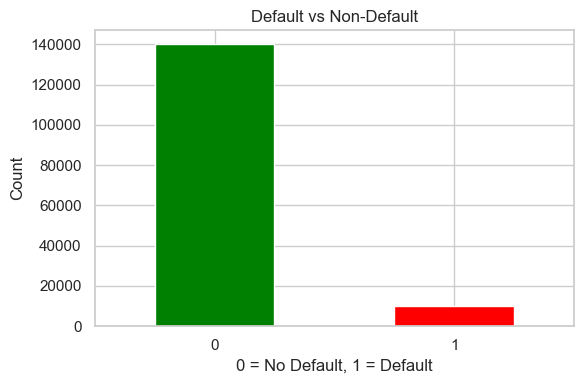

In [14]:
# Check how many defaults vs non-defaults
print('Target column: SeriousDlqin2yrs')
print('0 = No Default (Good) | 1 = Default (Bad)')
print()
print(df['SeriousDlqin2yrs'].value_counts())
print()

# Simple bar chart
plt.figure(figsize=(6, 4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Default vs Non-Default')
plt.xlabel('0 = No Default, 1 = Default')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 3 — Clean the Data

We will:
- Fill missing values with median (middle value)
- Remove very old/young ages
- That's it! Simple and effective.

In [15]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
print()

# Fill missing values with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Remove unrealistic ages (keep 18-100)
before = len(df)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
after = len(df)
print(f'Removed {before - after} rows with unrealistic ages')

# Confirm no missing values remain
print(f'\nRemaining missing values: {df.isnull().sum().sum()}')
print(f'Final dataset: {df.shape[0]} rows, {df.shape[1]} columns')

Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Removed 14 rows with unrealistic ages

Remaining missing values: 0
Final dataset: 149986 rows, 11 columns


## Step 4 — Split Data into Train & Test Sets

- **Train set (80%):** Used to teach the model
- **Test set (20%):** Used to check how well the model learned

In [16]:
# Separate features (X) from target (y)
TARGET = 'SeriousDlqin2yrs'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Training set: 119988 rows
Test set:     29998 rows


## Step 5 — Train the Model (Random Forest)

Random Forest is a powerful and easy-to-use model.
It builds many decision trees and combines their answers.

In [17]:
# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,     # 100 trees
    max_depth=10,         # limit tree depth to avoid overfitting
    random_state=42,
    class_weight='balanced'  # handle imbalanced classes
)

model.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


## Step 6 — Evaluate the Model

Let's see how well our model performs on the test data.

In [18]:
# Make predictions on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default

# Print accuracy
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')
print()

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

Accuracy: 82.01%
ROC-AUC Score: 0.8671

Classification Report:
              precision    recall  f1-score   support

  No Default       0.98      0.83      0.90     27993
     Default       0.23      0.74      0.36      2005

    accuracy                           0.82     29998
   macro avg       0.61      0.78      0.63     29998
weighted avg       0.93      0.82      0.86     29998



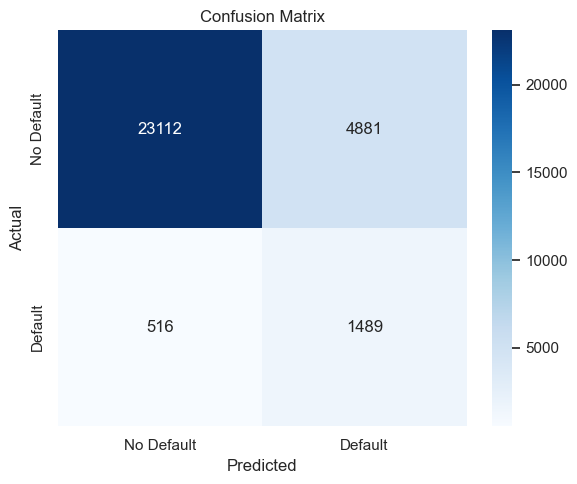

In [19]:
# Confusion Matrix (visual)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

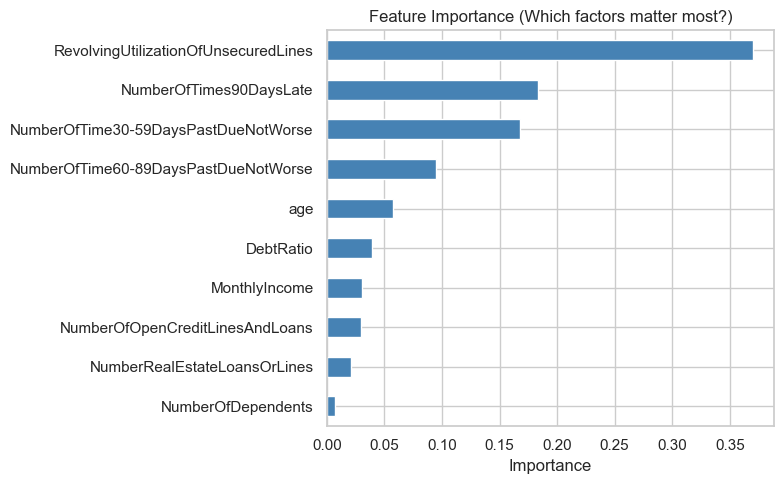

In [20]:
# Feature Importance — Which features matter most?
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Which factors matter most?)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Step 7 — Make a Prediction on New Data

Enter a person's details and see if the model thinks they will default.

In [21]:
# Example: Create a new applicant
new_applicant = pd.DataFrame([{
    'RevolvingUtilizationOfUnsecuredLines': 0.5,
    'age': 35,
    'NumberOfTime30-59DaysPastDueNotWorse': 0,
    'DebtRatio': 0.3,
    'MonthlyIncome': 5000,
    'NumberOfOpenCreditLinesAndLoans': 5,
    'NumberOfTimes90DaysLate': 0,
    'NumberRealEstateLoansOrLines': 1,
    'NumberOfTime60-89DaysPastDueNotWorse': 0,
    'NumberOfDependents': 2
}])

# Predict
prediction = model.predict(new_applicant)[0]
probability = model.predict_proba(new_applicant)[0][1]

print('=== New Applicant Prediction ===')
print(f'Result: {"⚠️ LIKELY TO DEFAULT" if prediction == 1 else "✅ NOT LIKELY TO DEFAULT"}')
print(f'Default Probability: {probability:.2%}')

=== New Applicant Prediction ===
Result: ✅ NOT LIKELY TO DEFAULT
Default Probability: 31.94%


## Step 8 — Save the Model

Save the trained model so you can use it later without retraining.

In [22]:
import joblib

# Save model
joblib.dump(model, 'credit_risk_model_simple.pkl')
print('✅ Model saved as: credit_risk_model_simple.pkl')

# To load later:
# loaded_model = joblib.load('credit_risk_model_simple.pkl')
# loaded_model.predict(new_data)

✅ Model saved as: credit_risk_model_simple.pkl


---
## ✅ Done!

### Summary:
- We loaded **150,000** loan records
- Cleaned missing values and bad data
- Trained a **Random Forest** model
- The model can predict if a new applicant will default
- Model is saved for future use

### What each column means:
| Column | Meaning |
|--------|--------|
| SeriousDlqin2yrs | **Target:** 1 = defaulted, 0 = did not |
| RevolvingUtilizationOfUnsecuredLines | How much credit they're using vs total credit |
| age | Borrower's age |
| NumberOfTime30-59DaysPastDueNotWorse | Times 30-59 days late |
| DebtRatio | Monthly debt payments / monthly income |
| MonthlyIncome | Monthly income in dollars |
| NumberOfOpenCreditLinesAndLoans | Number of open loans |
| NumberOfTimes90DaysLate | Times 90+ days late |
| NumberRealEstateLoansOrLines | Number of mortgage/real estate loans |
| NumberOfTime60-89DaysPastDueNotWorse | Times 60-89 days late |
| NumberOfDependents | Number of dependents (family members) |